# Análise Exploratória — Comissionamento Delivery

Objetivo: entender a distribuição dos dados de comissionamento, calcular AOV e identificar onde estão os parceiros de alto valor estratégico.

---
## 1. Setup

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath('..'))
from utils import plots_eda as eda

df = pd.read_csv('../data/base_delivery.csv')

---
## 2. Visão Geral do Dataset

Checagem inicial: shape, tipos, estatísticas descritivas e nulos.

In [56]:
def resumo(df):
    """
    Exibe shape, info, estatísticas descritivas e valores únicos
    das colunas categóricas. Informa se há nulos.
    """
    print(f'Shape: {df.shape}')
    print(df.info())

    print('\nEstatísticas descritivas:')
    display(df.describe().round(2))

    print('\nValores únicos (colunas categóricas):')
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        unicos = df[col].unique()
        print(f'  {col} ({len(unicos)}): {unicos}')

    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print('\nColunas com nulos:')
        print(nulos)
    else:
        print('\nSem valores nulos ✅')

resumo(df)

Shape: (18000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   reference_month             18000 non-null  str    
 1   frn_id                      18000 non-null  str    
 2   group_name                  18000 non-null  str    
 3   performance_classification  18000 non-null  str    
 4   business_model              18000 non-null  str    
 5   orders                      18000 non-null  int64  
 6   gmv_basket                  18000 non-null  float64
 7   delivery_fee                18000 non-null  float64
 8   paid_delivery_fee           18000 non-null  float64
 9   commission                  18000 non-null  float64
 10  service_fee                 18000 non-null  float64
 11  anticipation_fee            18000 non-null  float64
 12  olp_fee                     18000 non-null  float64
 13  delivery_cost          

,orders,gmv_basket,delivery_fee,paid_delivery_fee,commission,service_fee,anticipation_fee,olp_fee,delivery_cost,occurrences_cost
count,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00
mean,363.44,38552.28,2666.15,1999.61,5462.34,771.05,130.06,578.28,-988.43,-141.20
std,411.12,71512.46,5407.44,4055.58,9422.33,1430.25,322.33,1072.69,3622.32,517.47
min,1.00,16.51,0.99,0.74,2.64,0.33,0.03,0.25,-47759.35,-6822.76
25%,78.00,3866.15,241.10,180.83,591.04,77.32,8.60,57.99,0.00,0.00
50%,256.50,15367.22,951.08,713.31,2361.43,307.34,33.69,230.51,0.00,0.00
75%,435.00,35355.62,2270.44,1702.82,5338.77,707.11,86.20,530.34,0.00,0.00
max,2832.00,852845.59,68227.65,51170.74,102341.47,17056.91,4264.23,12792.68,0.00,0.00



Valores únicos (colunas categóricas):
  reference_month (6): <StringArray>
['2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11']
Length: 6, dtype: str
  frn_id (3000): <StringArray>
['FRN_00001', 'FRN_00002', 'FRN_00003', 'FRN_00004', 'FRN_00005', 'FRN_00006',
 'FRN_00007', 'FRN_00008', 'FRN_00009', 'FRN_00010',
 ...
 'FRN_02991', 'FRN_02992', 'FRN_02993', 'FRN_02994', 'FRN_02995', 'FRN_02996',
 'FRN_02997', 'FRN_02998', 'FRN_02999', 'FRN_03000']
Length: 3000, dtype: str
  group_name (400): <StringArray>
['GRUPO_103', 'GRUPO_349', 'GRUPO_271', 'GRUPO_107', 'GRUPO_072', 'GRUPO_189',
 'GRUPO_021', 'GRUPO_122', 'GRUPO_215', 'GRUPO_331',
 ...
 'GRUPO_193', 'GRUPO_232', 'GRUPO_102', 'GRUPO_245', 'GRUPO_077', 'GRUPO_079',
 'GRUPO_024', 'GRUPO_276', 'GRUPO_071', 'GRUPO_248']
Length: 400, dtype: str
  performance_classification (4): <StringArray>
['STANDARD', 'LONG_TAIL', 'STRATEGIC', 'KEY_ACCOUNT']
Length: 4, dtype: str
  business_model (2): <StringArray>
['MARKETPLACE', 'FULL_S

C:\Users\thiag\AppData\Local\Temp\ipykernel_27900\3662216204.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


> **Output esperado:** Shape `(N linhas, 15 colunas)` → tabela de estatísticas descritivas com min/max/média/std de cada coluna numérica → valores únicos das colunas categóricas (`business_model`, `performance_classification`, `reference_month`) → confirmação de ausência de nulos.

---
## 3. Volume de Pedidos

Análise da variável `orders`: evolução mensal e distribuição por modelo de negócio.

### 3.1 Evolução mensal de pedidos

Verifica sazonalidade e tendência ao longo do período.

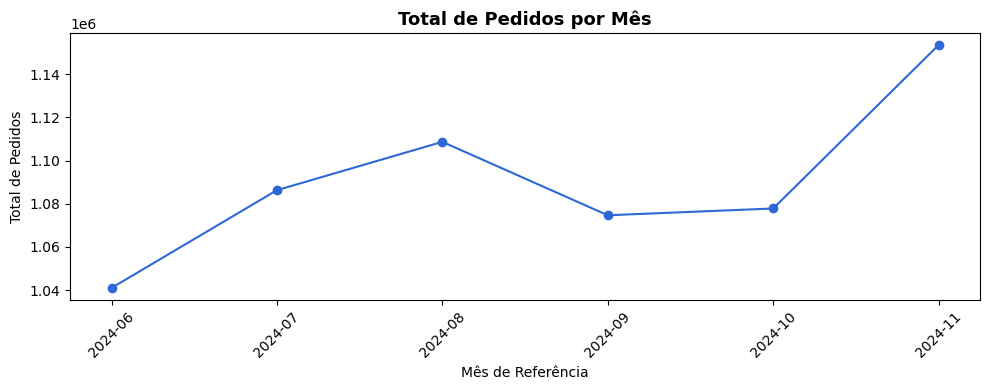

In [57]:
serie_mensal = df.groupby('reference_month')['orders'].sum()

serie_mensal.plot(kind='line', marker='o', figsize=(10, 4), color='#2D68D6')
plt.title('Total de Pedidos por Mês', fontsize=13, fontweight='bold')
plt.xlabel('Mês de Referência')
plt.ylabel('Total de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Output esperado:** Gráfico de linha com um ponto por mês. Espera-se variação leve entre meses — novembro ligeiramente acima dos demais por sazonalidade. Tendência plana confirma que os dados são estáveis para análise de comissionamento.

### 3.2 Pedidos por modelo de negócio

Compara o volume total entre FULL_SERVICE e MARKETPLACE.

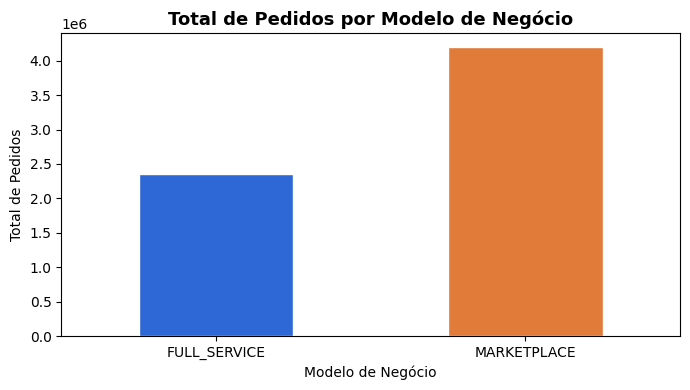

In [58]:
pedidos_modelo = df.groupby('business_model')['orders'].sum()

pedidos_modelo.plot(kind='bar', figsize=(7, 4),
                   color=['#2D68D6', '#E07B39'], edgecolor='white', width=0.5)
plt.title('Total de Pedidos por Modelo de Negócio', fontsize=13, fontweight='bold')
plt.xlabel('Modelo de Negócio')
plt.ylabel('Total de Pedidos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> **Output esperado:** Duas barras: FULL_SERVICE (azul) e MARKETPLACE (laranja). MARKETPLACE deve aparecer significativamente maior, refletindo que ~79% dos parceiros usam logística própria. Essa desproporção é o ponto de partida da análise estratégica.

### 3.3 Distribuição de pedidos por restaurante

Histograma com boxplot para identificar assimetria e outliers em `orders`.

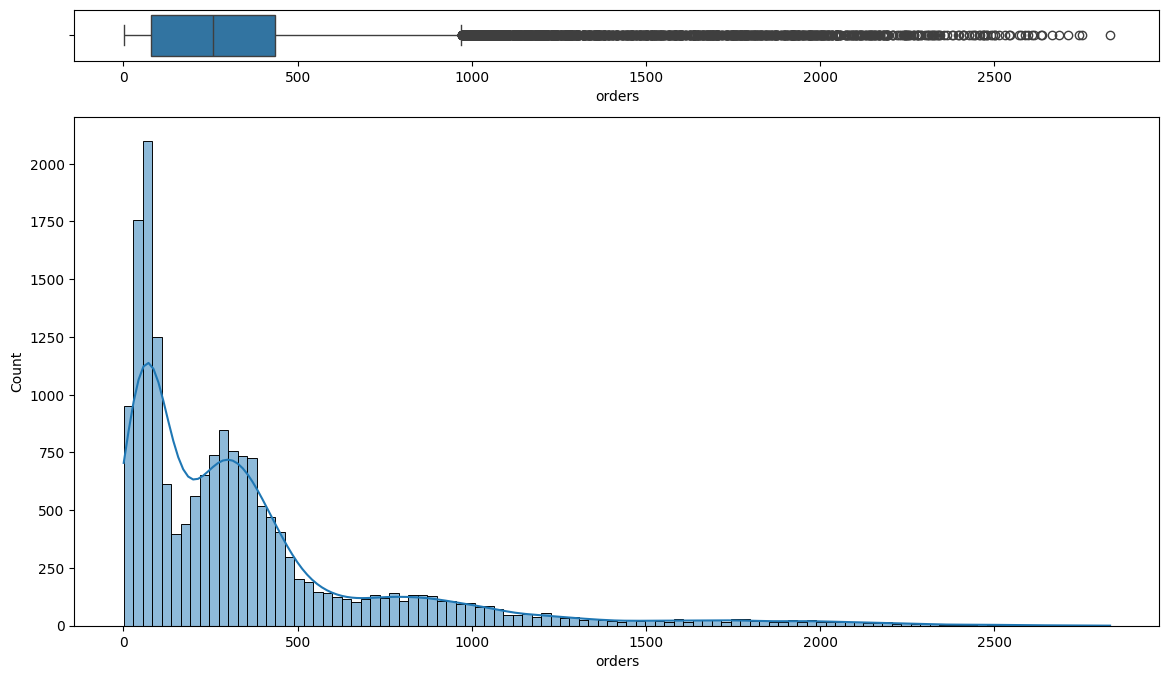

In [59]:
eda.histogram_plot(df, variable_name='orders')

> **Output esperado:** Boxplot superior + histograma inferior. Distribuição com forte assimetria à direita (right-skewed): pico entre 50–100 pedidos/mês com cauda se estendendo até ~2.500. Dois picos visíveis refletem a mistura de LONG_TAIL (baixo volume) e KEY_ACCOUNT (alto volume). Outliers no boxplot além de 1.500 são os parceiros estratégicos de maior volume.

---
## 4. GMV (Valor dos Pedidos)

Análise de `gmv_basket`: distribuição bruta e transformação logarítmica para visualização da estrutura real dos dados.

> **Por que log?** O GMV tem cauda longa — poucos restaurantes concentram volume muito alto. O `log1p` comprime a escala e permite enxergar a distribuição completa sem os outliers esmagar os demais valores.

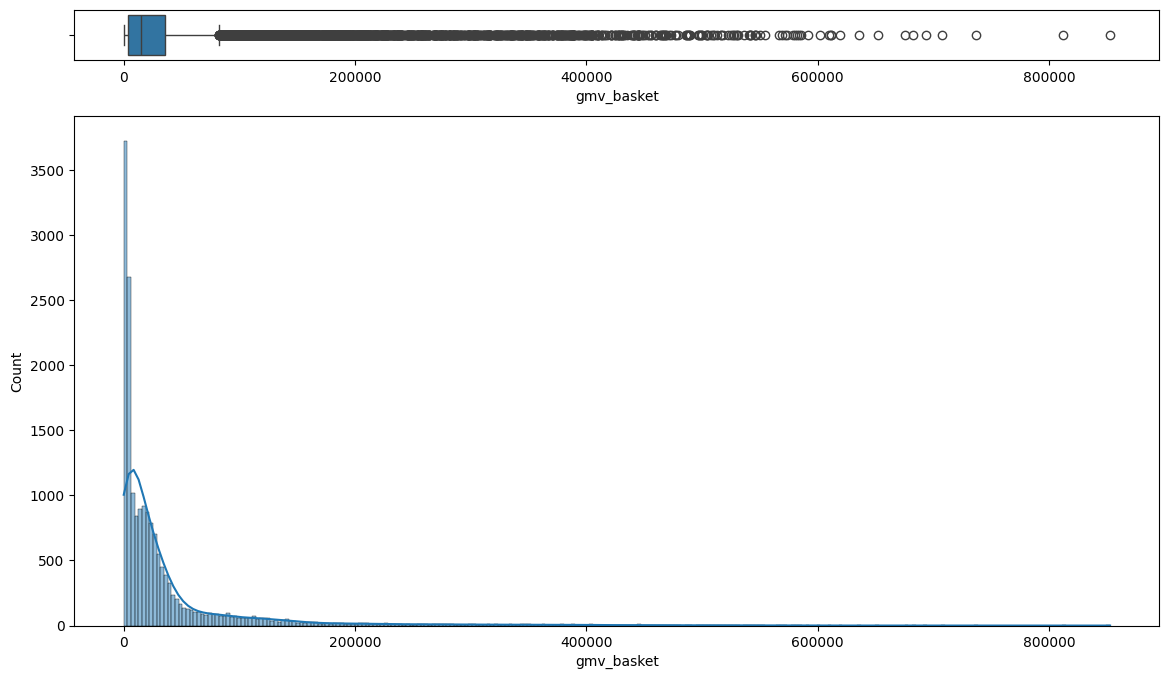

In [60]:
eda.histogram_plot(df, variable_name='gmv_basket')

> **Output esperado:** Assimetria extrema: caixa do boxplot quase invisível perto do zero, com dezenas de outliers espalhados até R$850.000. Histograma com pico único concentrado entre R$5.000–15.000. Confirma que a maioria dos parceiros tem GMV baixo, mas poucos concentram volume estratégico alto.

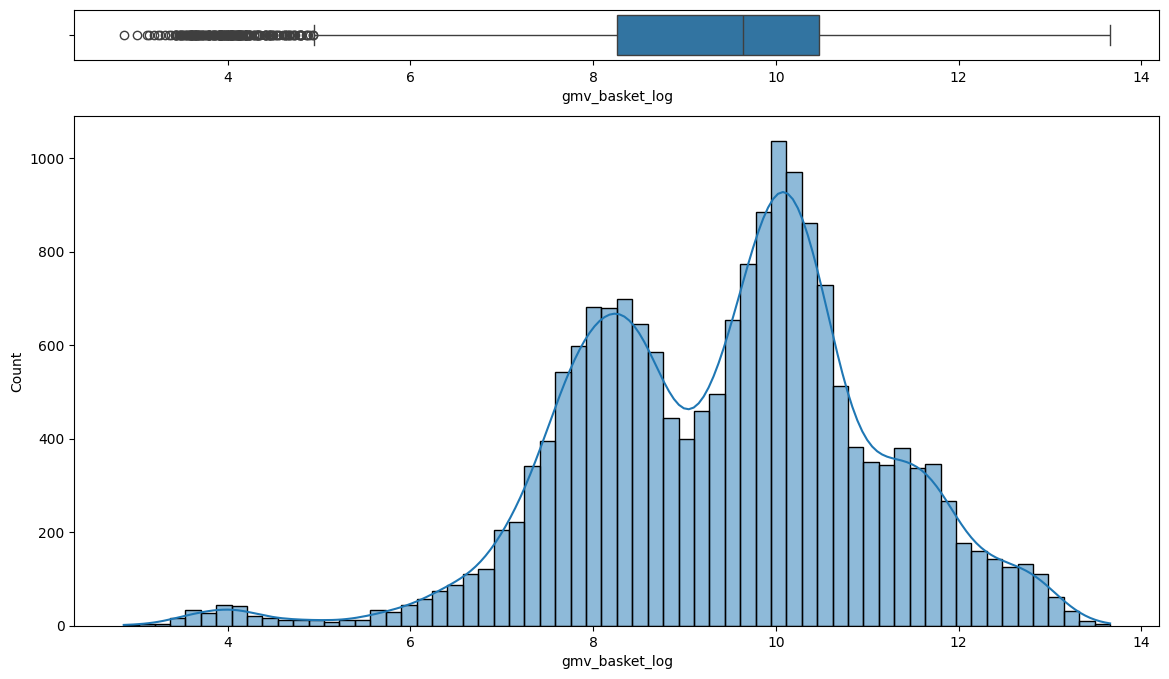

In [61]:
df['gmv_basket_log'] = np.log1p(df['gmv_basket'])
eda.histogram_plot(df, variable_name='gmv_basket_log')

> **Output esperado:** Distribuição mais simétrica e legível após transformação log. Múltiplos grupos ficam visíveis — LONG_TAIL, STANDARD e KEY_ACCOUNT aparecem como faixas distintas. Confirma que a variável tem estrutura multimodal escondida pela escala original.

---
## 5. AOV — Average Order Value

`AOV = gmv_basket / orders`

Classifica cada restaurante em baixo/médio/alto com base nos quartis Q1 e Q3. O IQR identifica outliers estatísticos extremos.

| Classificação | Critério | Interpretação |
|---|---|---|
| `baixo` | AOV < Q1 | Ticket pequeno — LONG_TAIL |
| `medio` | Q1 ≤ AOV ≤ Q3 | Faixa intermediária |
| `alto` | AOV > Q3 | Alto ticket — candidatos à migração FS |

In [62]:
df['aov'] = round(df['gmv_basket'] / df['orders'], 2)

q1 = df['aov'].quantile(0.25)
q3 = df['aov'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df['aov_classificacao'] = df['aov'].apply(
    lambda x: 'baixo' if x < q1 else ('alto' if x > q3 else 'medio')
)

outliers = df[(df['aov'] < lower_bound) | (df['aov'] > upper_bound)]

print(f'Q1: R$ {q1:.2f} | Q3: R$ {q3:.2f} | IQR: R$ {iqr:.2f}')
print(f'Lower bound: R$ {lower_bound:.2f} | Upper bound: R$ {upper_bound:.2f}')
print(f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

Q1: R$ 47.44 | Q3: R$ 93.81 | IQR: R$ 46.38
Lower bound: R$ -22.12 | Upper bound: R$ 163.38
Outliers: 762 (4.2%)


> **Output esperado:** Três linhas impressas: Q1/Q3/IQR em R$ → limites inferior e superior → contagem de outliers. Lower bound próximo de R$3 indica ausência de outliers negativos relevantes. Outliers concentrados no upper bound são os KEY_ACCOUNT com ticket bem acima da média — não devem ser removidos, são o foco estratégico do case.

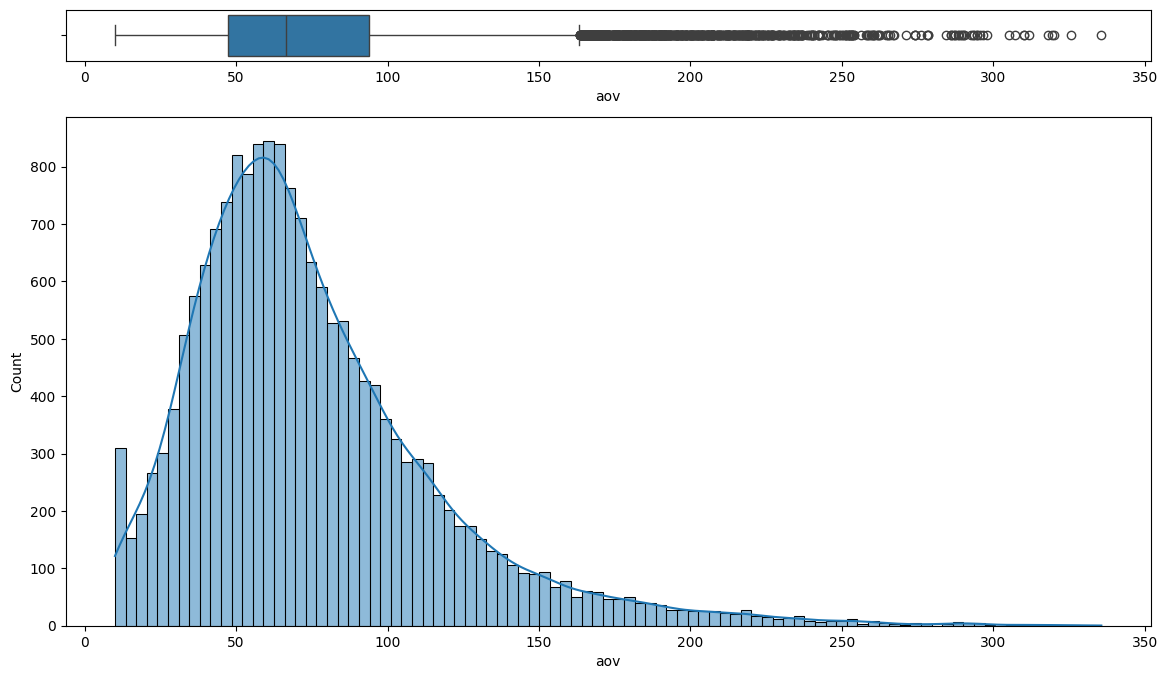

In [63]:
eda.histogram_plot(df, variable_name='aov')

> **Output esperado:** Histograma do AOV com dois picos: um concentrado em ~R$50 (LONG_TAIL/STANDARD) e outro em ~R$110 (KEY_ACCOUNT/STRATEGIC). Cauda direita com alguns outliers acima de R$180 — parceiros de alto valor individual. O boxplot confirma a assimetria com mediana abaixo da média.

---
## 6. AOV × Modelo de Negócio

Cruzamento central do case: onde estão os parceiros de alto AOV? Se a maioria estiver no MARKETPLACE, há oportunidade de migração para FULL_SERVICE.

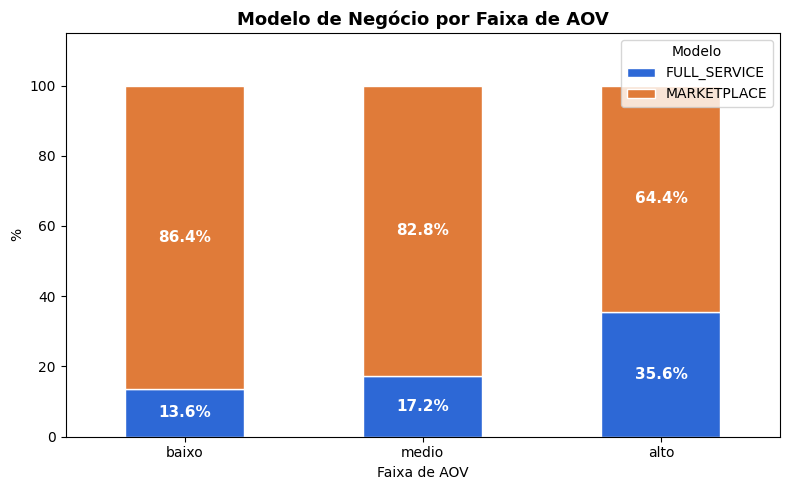

In [64]:
ordem = ['baixo', 'medio', 'alto']

avaliacao_model_aov = (
    df.groupby(['aov_classificacao', 'business_model'])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem)
)

aov_pct = avaliacao_model_aov.div(avaliacao_model_aov.sum(axis=1), axis=0) * 100

ax = aov_pct.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=['#2D68D6', '#E07B39'], edgecolor='white', width=0.5
)
plt.title('Modelo de Negócio por Faixa de AOV', fontsize=13, fontweight='bold')
plt.xlabel('Faixa de AOV')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.ylim(0, 115)
plt.legend(title='Modelo', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center',
                 color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

> **Output esperado:** Barras empilhadas em % para as 3 faixas de AOV. Resultado esperado: ~64% dos parceiros de alto AOV estão no MARKETPLACE — esse é o número central que justifica a estratégia de migração. Baixo e médio AOV têm ~83–86% no MARKETPLACE, o que é esperado e menos crítico estrategicamente.

### Oportunidade identificada

Parceiros de alto AOV no MARKETPLACE são os candidatos prioritários para migração para FULL_SERVICE — são os que mais impactam a receita por unidade e sobre os quais a plataforma tem menor controle do nível de serviço.

In [65]:
oportunidade = df[
    (df['aov_classificacao'] == 'alto') &
    (df['business_model'] == 'MARKETPLACE')
]

print(f'Restaurantes alto AOV no MARKETPLACE: {oportunidade["frn_id"].nunique():,}')
print(f'GMV total:                            R$ {oportunidade["gmv_basket"].sum():,.0f}')
print(f'Comissão atual (MP):                  R$ {oportunidade["commission"].sum():,.0f}')

Restaurantes alto AOV no MARKETPLACE: 1,260
GMV total:                            R$ 225,298,774
Comissão atual (MP):                  R$ 36,047,804


> **Output esperado:** Três métricas impressas: número de parceiros únicos de alto AOV no MARKETPLACE → GMV total que eles representam → comissão atual gerada por eles no modelo MP. Esses valores são a base para calcular o upside de receita ao migrar esses parceiros para FULL_SERVICE.